In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [14]:
# Navigate into the data subfolder 
df = pd.read_csv('Datasets/student_habits_performance.csv')
print(df.head())
print(df.info())

  student_id  age  gender  study_hours_per_day  social_media_hours  \
0      S1000   23  Female                  0.0                 1.2   
1      S1001   20  Female                  6.9                 2.8   
2      S1002   21    Male                  1.4                 3.1   
3      S1003   23  Female                  1.0                 3.9   
4      S1004   19  Female                  5.0                 4.4   

   netflix_hours part_time_job  attendance_percentage  sleep_hours  \
0            1.1            No                   85.0          8.0   
1            2.3            No                   97.3          4.6   
2            1.3            No                   94.8          8.0   
3            1.0            No                   71.0          9.2   
4            0.5            No                   90.9          4.9   

  diet_quality  exercise_frequency parental_education_level internet_quality  \
0         Fair                   6                   Master          Average  

In [15]:
from sklearn.model_selection import train_test_split

# 1. Drop the 'student_id' column
df = df.drop('student_id', axis=1)

# 2. Handle missing values in 'parental_education_level' with the mode
mode_parental_education = df['parental_education_level'].mode()[0]
df['parental_education_level'].fillna(mode_parental_education, inplace=True)

# 3. Identify all remaining categorical columns (object type)
categorical_cols = df.select_dtypes(include=['object']).columns

# 4. Apply one-hot encoding to these identified categorical columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# 5. Separate the features (X) from the target variable (y)
X = df_encoded.drop('exam_score', axis=1)
y = df_encoded['exam_score']

# 6. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (800, 18)
Shape of X_test: (200, 18)
Shape of y_train: (800,)
Shape of y_test: (200,)


C:\Users\Rabbi\AppData\Local\Temp\ipykernel_46628\4164720944.py:8: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['parental_education_level'].fillna(mode_parental_education, inplace=True)
C:\Users\Rabbi\AppData\Local\Temp\ipykernel_46628\4164720944.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by sele

In [16]:
from sklearn.model_selection import train_test_split

# 1. Drop the 'student_id' column if it exists
if 'student_id' in df.columns:
    df = df.drop('student_id', axis=1)

# 2. Handle missing values in 'parental_education_level' with the mode
mode_parental_education = df['parental_education_level'].mode()[0]
df['parental_education_level'] = df['parental_education_level'].fillna(mode_parental_education)

# 3. Identify all remaining categorical columns (object type)
categorical_cols = df.select_dtypes(include=['object']).columns

# 4. Apply one-hot encoding to these identified categorical columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# 5. Separate the features (X) from the target variable (y)
X = df_encoded.drop('exam_score', axis=1)
y = df_encoded['exam_score']

# 6. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (800, 18)
Shape of X_test: (200, 18)
Shape of y_train: (800,)
Shape of y_test: (200,)


C:\Users\Rabbi\AppData\Local\Temp\ipykernel_46628\3053230048.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


In [17]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Instantiate an XGBRegressor model
xgb_model = xgb.XGBRegressor(random_state=42)

# 2. Train the XGBoost model
xgb_model.fit(X_train, y_train)

# 3. Make predictions on the X_test dataset
y_pred_xgb = xgb_model.predict(X_test)

# 4. Calculate and print the evaluation metrics
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost Model Performance:\n")
print(f"Mean Absolute Error (MAE): {mae_xgb:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_xgb:.2f}")
print(f"R-squared (R2) Score: {r2_xgb:.2f}")

XGBoost Model Performance:

Mean Absolute Error (MAE): 5.13
Root Mean Squared Error (RMSE): 6.36
R-squared (R2) Score: 0.84


In [18]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Instantiate a RandomForestRegressor model
rf_model = RandomForestRegressor(random_state=42)

# 2. Train the Random Forest model
rf_model.fit(X_train, y_train)

# 3. Make predictions on the X_test dataset
y_pred_rf = rf_model.predict(X_test)

# 4. Calculate and print the evaluation metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest Model Performance:\n")
print(f"Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf:.2f}")
print(f"R-squared (R2) Score: {r2_rf:.2f}")

Random Forest Model Performance:

Mean Absolute Error (MAE): 4.98
Root Mean Squared Error (RMSE): 6.24
R-squared (R2) Score: 0.85


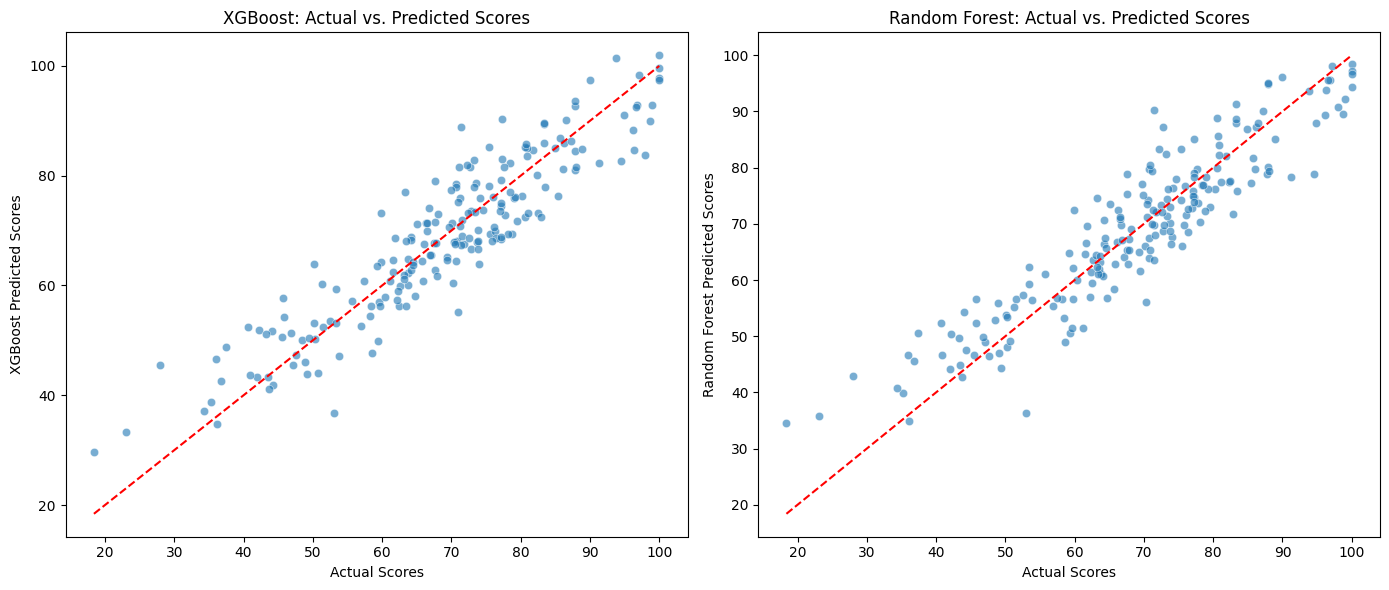

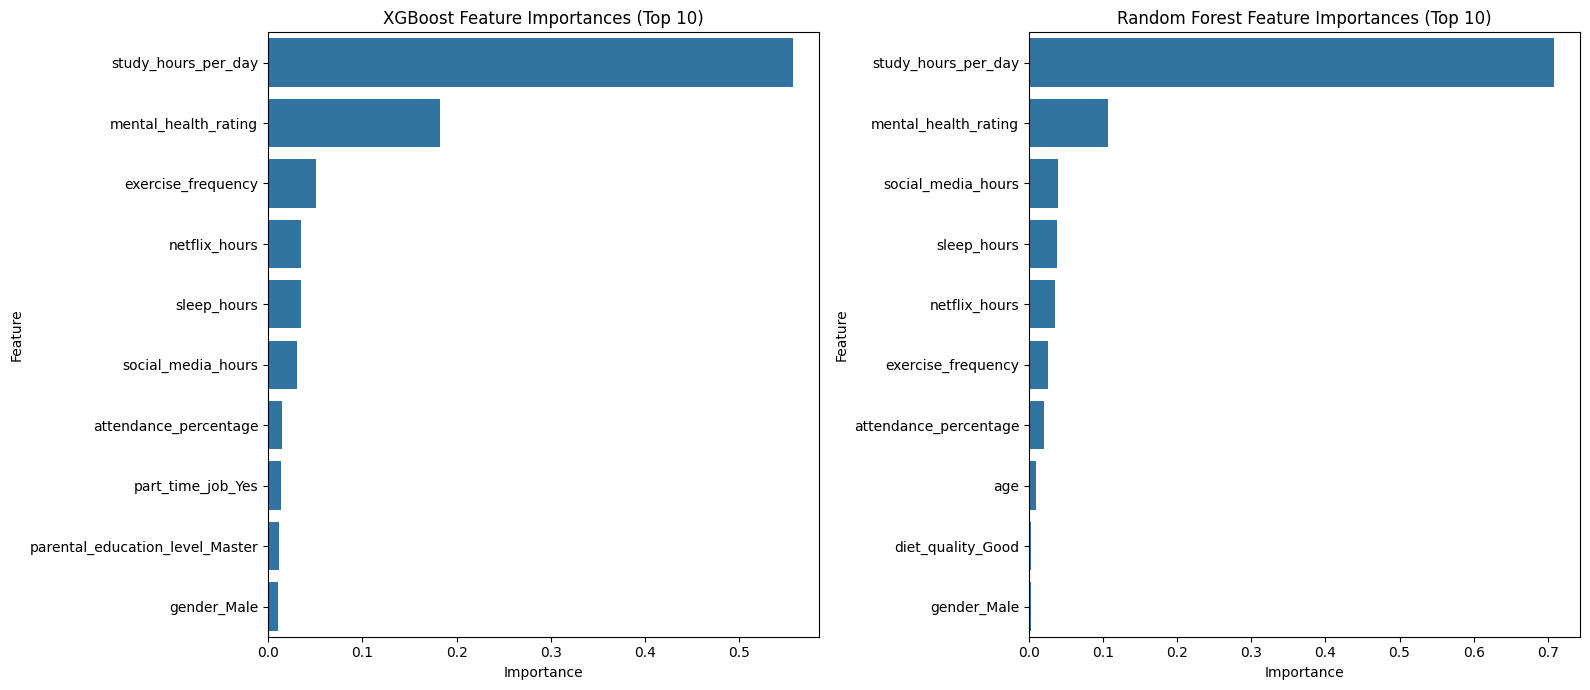

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Predicted vs. Actual Plots
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
sns.scatterplot(x=y_test, y=y_pred_xgb, alpha=0.6)
sns.lineplot(x=[y_test.min(), y_test.max()], y=[y_test.min(), y_test.max()], color='red', linestyle='--')
plt.title('XGBoost: Actual vs. Predicted Scores')
plt.xlabel('Actual Scores')
plt.ylabel('XGBoost Predicted Scores')

plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.6)
sns.lineplot(x=[y_test.min(), y_test.max()], y=[y_test.min(), y_test.max()], color='red', linestyle='--')
plt.title('Random Forest: Actual vs. Predicted Scores')
plt.xlabel('Actual Scores')
plt.ylabel('Random Forest Predicted Scores')

plt.tight_layout()
plt.show()

# Feature Importance Plots
# XGBoost Feature Importance
xgb_feature_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

# Random Forest Feature Importance
rf_feature_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(16, 7))

plt.subplot(1, 2, 1)
sns.barplot(x='importance', y='feature', data=xgb_feature_importances.head(10))
plt.title('XGBoost Feature Importances (Top 10)')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.subplot(1, 2, 2)
sns.barplot(x='importance', y='feature', data=rf_feature_importances.head(10))
plt.title('Random Forest Feature Importances (Top 10)')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()